# BIS Credit Growth Prediction
## Machine Learning Final Project

**Student:** Drichiru Faith   
**Dataset:** BIS Total Credit to Private Non-Financial Sector  
**Source:** https://www.bis.org/statistics/totcredit.htm  
**ML Task:** Regression — Predicting Quarterly Credit Growth Rate (% of GDP)  
**GitHub:** https://github.com/Chirumatic/BIS-Credit-Growth-ML

---

## Table of Contents
1. Data Description
2. Data Exploration & Visualization
3. Data Cleaning & Preparation
4. Modelling & Evaluation
5. Neural Network
6. Demo Interface
7. Findings & Conclusion

## 1. Data Description

### Dataset Overview
The dataset is sourced from the **Bank for International Settlements (BIS)**,
specifically the Total Credit to the Private Non-Financial Sector statistics.
It captures borrowing activity across 42 countries over 50+ years.

### Source
- **Provider:** Bank for International Settlements (BIS)
- **URL:** https://www.bis.org/statistics/totcredit.htm
- **Last Updated:** March 2026

### Dataset Characteristics
- **Rows:** 2,032 (after filtering to % of GDP and private sector)
- **Raw Rows:** 21,437
- **Countries:** 42
- **Time Period:** 1961 – 2024
- **Frequency:** Quarterly

### Features
| Feature | Description |
|---|---|
| ref_area | Country name |
| date | Quarter and year (e.g. 2010-Q1) |
| value | Total credit as % of GDP |
| lag_1 to lag_4 | Previous 1–4 quarters credit values |
| rolling_4 | 4-quarter rolling average |
| rolling_8 | 8-quarter rolling average |
| credit_acceleration | Rate of change of credit growth |
| year / quarter | Extracted time features |
| country dummies | One-hot encoded country indicators |

### Target Variable
- **credit_growth** — Quarterly percentage change in credit-to-GDP ratio

In [4]:
import pandas as pd

# Placeholder for df definition. In a real scenario, you would load your data here.
# For example: df = pd.read_csv('your_dataset.csv')
# Based on the description, creating a minimal DataFrame to avoid the NameError.
data = {
    'ref_area': ['CountryA', 'CountryB', 'CountryA', 'CountryB'],
    'date': ['2020-Q1', '2020-Q1', '2020-Q2', '2020-Q2'],
    'value': [100.0, 150.0, 102.5, 153.0],
    'credit_growth': [2.5, 3.0, 2.0, 2.8]
}
df = pd.DataFrame(data)
# Convert 'date' column to datetime objects for proper min/max operations and sorting
df['date'] = pd.to_datetime(df['date'].str.replace(r'Q(\d)', lambda m: f'-{(int(m.group(1))-1)*3+1:02d}-01', regex=True))

# Helper function to format date to YYYY-Qx
def format_quarter(dt):
    return f"{dt.year}-Q{(dt.month-1)//3 + 1}"

# Dataset summary
print("=== DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"\nDate range: {format_quarter(df['date'].min())} to {format_quarter(df['date'].max())}")
print(f"Number of countries: {df['ref_area'].nunique()}")
print(f"\nFeature types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget variable (credit_growth) summary:")
print(df['credit_growth'].describe())

=== DATASET SUMMARY ===
Shape: (4, 4)

Date range: 2020-Q1 to 2020-Q2
Number of countries: 2

Feature types:
ref_area                 object
date             datetime64[ns]
value                   float64
credit_growth           float64
dtype: object

Missing values:
ref_area         0
date             0
value            0
credit_growth    0
dtype: int64

Target variable (credit_growth) summary:
count    4.000000
mean     2.575000
std      0.434933
min      2.000000
25%      2.375000
50%      2.650000
75%      2.850000
max      3.000000
Name: credit_growth, dtype: float64


In [5]:
# Installind & Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
# Loading Dataset

from google.colab import files
uploaded = files.upload()

Saving WS_TC_csv_flat.zip to WS_TC_csv_flat.zip


In [7]:
# Unziping the file
import zipfile

with zipfile.ZipFile('WS_TC_csv_flat.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
    print("Files extracted:", zip_ref.namelist())

Files extracted: ['WS_TC_csv_flat.csv']


In [8]:
# Loading & Previewing Dataset

df_raw = pd.read_csv('WS_TC_csv_flat.csv',
                     sep=',',
                     encoding='utf-8',
                     quotechar='"',
                     on_bad_lines='warn',
                     engine='python')

# Renaming all 20 columns correctly
df_raw.columns = [
    'dataflow', 'series_key', 'frequency', 'ref_area', 'borrower_sector',
    'lending_sector', 'valuation', 'currency_type', 'adjustment',
    'date', 'value', 'position', 'unit_mult', 'currency',
    'series_name', 'col16', 'obs_status', 'col18', 'col19', 'col20'
]

print(f"Raw dataset shape: {df_raw.shape}")
print(f"\nFirst 5 rows:")
print(df_raw.head())

Raw dataset shape: (186082, 20)

First 5 rows:
   dataflow                    series_key frequency ref_area  \
0  dataflow  BIS:WS_TC(2.0): Total credit         I      NaN   
1  dataflow  BIS:WS_TC(2.0): Total credit         I      NaN   
2  dataflow  BIS:WS_TC(2.0): Total credit         I      NaN   
3  dataflow  BIS:WS_TC(2.0): Total credit         I      NaN   
4  dataflow  BIS:WS_TC(2.0): Total credit         I      NaN   

      borrower_sector                   lending_sector       valuation  \
0         HU: Hungary            G: General government  A: All sectors   
1         IE: Ireland          C: Non financial sector  A: All sectors   
2  GB: United Kingdom            G: General government  A: All sectors   
3         BE: Belgium  P: Private non-financial sector  A: All sectors   
4           KR: Korea    N: Non-financial corporations  A: All sectors   

      currency_type                                         adjustment  \
0  N: Nominal value                             7

In [9]:
# Cleaning & Filter Dataset

# Fixing column mapping based on actual structure
df = df_raw.copy()

# Renaming columns correctly based on what we see
df = df.rename(columns={
    'ref_area': 'drop1',
    'borrower_sector': 'ref_area',
    'lending_sector': 'borrower_sector',
    'valuation': 'lending_sector',
    'currency_type': 'valuation',
    'adjustment': 'currency_type',
    'date': 'adjustment',
    'value': 'date',
    'position': 'value'
})

# Cleaning up ref_area and borrower_sector
df['ref_area'] = df['ref_area'].str.split(': ').str[-1]
df['borrower_sector'] = df['borrower_sector'].str.split(': ').str[-1]
df['currency_type'] = df['currency_type'].str.split(': ').str[-1]

# Filtering to % of GDP and Private non-financial sector only
df = df[df['currency_type'] == 'Percentage of GDP']
df = df[df['borrower_sector'] == 'Private non-financial sector']

# Converting value to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df = df.dropna(subset=['value'])

print(df.shape)
print(df[['ref_area', 'borrower_sector', 'date', 'value', 'currency_type']].head(10))
print("\nUnique countries:", df['ref_area'].unique())

(19399, 20)
     ref_area               borrower_sector     date  value      currency_type
1360  Austria  Private non-financial sector  1960-Q4   20.7  Percentage of GDP
1361  Austria  Private non-financial sector  1961-Q1   20.9  Percentage of GDP
1362  Austria  Private non-financial sector  1961-Q2   21.5  Percentage of GDP
1363  Austria  Private non-financial sector  1961-Q3   21.6  Percentage of GDP
1364  Austria  Private non-financial sector  1961-Q4   21.7  Percentage of GDP
1365  Austria  Private non-financial sector  1962-Q1   22.1  Percentage of GDP
1366  Austria  Private non-financial sector  1962-Q2   22.3  Percentage of GDP
1367  Austria  Private non-financial sector  1962-Q3   22.3  Percentage of GDP
1368  Austria  Private non-financial sector  1962-Q4   22.4  Percentage of GDP
1369  Austria  Private non-financial sector  1963-Q1   22.8  Percentage of GDP

Unique countries: ['Austria' 'Israel' 'Sweden' 'Euro area' 'Indonesia' 'Russia'
 'G20 economies' 'Luxembourg' 'Mexico'

In [10]:
#  Feature Engineering

# Keeping only individual countries (removing aggregates)
aggregates = ['Euro area', 'G20 economies', 'All reporting economies',
              'Emerging market economies (aggregate)', 'Advanced economies']
df = df[~df['ref_area'].isin(aggregates)]

# Keeping only relevant columns
df = df[['ref_area', 'borrower_sector', 'date', 'value']].copy()

# Sorting by country and date
df = df.sort_values(['ref_area', 'date']).reset_index(drop=True)

# Calculating quarterly credit growth rate (target variable)
df['credit_growth'] = df.groupby('ref_area')['value'].pct_change() * 100

# Creating lag features
df['lag_1'] = df.groupby('ref_area')['value'].shift(1)
df['lag_2'] = df.groupby('ref_area')['value'].shift(2)
df['lag_3'] = df.groupby('ref_area')['value'].shift(3)
df['lag_4'] = df.groupby('ref_area')['value'].shift(4)

# Rolling averages
df['rolling_4'] = df.groupby('ref_area')['value'].transform(lambda x: x.rolling(4).mean())
df['rolling_8'] = df.groupby('ref_area')['value'].transform(lambda x: x.rolling(8).mean())

# Crediting acceleration
df['credit_acceleration'] = df.groupby('ref_area')['credit_growth'].diff()

# Extracting year and quarter
df['year'] = df['date'].str.split('-').str[0].astype(int)
df['quarter'] = df['date'].str.split('-Q').str[1].astype(int)

# One-hot encode country
country_dummies = pd.get_dummies(df['ref_area'], prefix='country')
df = pd.concat([df, country_dummies], axis=1)

# Dropping NaN rows
df = df.dropna()

print(f"Final dataset shape: {df.shape}")
print(f"Countries: {df['ref_area'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nTarget variable stats:")
print(df['credit_growth'].describe())

Final dataset shape: (17983, 57)
Countries: 43
Date range: 1948-Q3 to 2025-Q3

Target variable stats:
count    17983.000000
mean        20.383221
std         77.805951
min        -86.225112
25%        -36.476016
50%          0.000000
75%         58.068893
max        629.629630
Name: credit_growth, dtype: float64


In [11]:
# Remove Duplicates & Fix Data

# Go back to filtered data before feature engineering
df = df_raw.copy()

# Renaming columns correctly
df = df.rename(columns={
    'ref_area': 'drop1',
    'borrower_sector': 'ref_area',
    'lending_sector': 'borrower_sector',
    'valuation': 'lending_sector',
    'currency_type': 'valuation',
    'adjustment': 'currency_type',
    'date': 'adjustment',
    'value': 'date',
    'position': 'value'
})

# Cleaning columns
df['ref_area'] = df['ref_area'].str.split(': ').str[-1]
df['borrower_sector'] = df['borrower_sector'].str.split(': ').str[-1]
df['currency_type'] = df['currency_type'].str.split(': ').str[-1]
df['adjustment'] = df['adjustment'].str.split(': ').str[-1]

# Filtering strictly
df = df[df['currency_type'] == 'Percentage of GDP']
df = df[df['borrower_sector'] == 'Private non-financial sector']
df = df[df['adjustment'] == 'Unadjusted']  # Remove adjusted duplicates

# Removing aggregates
aggregates = ['Euro area', 'G20 economies', 'All reporting economies',
              'Emerging market economies (aggregate)', 'Advanced economies']
df = df[~df['ref_area'].isin(aggregates)]

# Keeping only relevant columns
df = df[['ref_area', 'date', 'value']].copy()

# Converting value to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df = df.dropna(subset=['value'])

# Checking for duplicates
print("Duplicates:", df.duplicated(subset=['ref_area', 'date']).sum())
print(f"Shape: {df.shape}")
print(f"Countries: {df['ref_area'].nunique()}")
print(df.head(10))

Duplicates: 0
Shape: (0, 3)
Countries: 0
Empty DataFrame
Columns: [ref_area, date, value]
Index: []


In [12]:
# Checking what's actually in the adjustment/unadjusted column
df_check = df_raw.copy()
df_check = df_check.rename(columns={
    'ref_area': 'drop1',
    'borrower_sector': 'ref_area',
    'lending_sector': 'borrower_sector',
    'valuation': 'lending_sector',
    'currency_type': 'valuation',
    'adjustment': 'currency_type',
    'date': 'adjustment',
    'value': 'date',
    'position': 'value'
})

df_check['currency_type'] = df_check['currency_type'].str.split(': ').str[-1]
df_check['borrower_sector'] = df_check['borrower_sector'].str.split(': ').str[-1]
df_check['adjustment'] = df_check['adjustment'].str.split(': ').str[-1]

# Filtering to % of GDP and private sector first
df_check = df_check[df_check['currency_type'] == 'Percentage of GDP']
df_check = df_check[df_check['borrower_sector'] == 'Private non-financial sector']

# Checking unique adjustment values
print("Unique adjustment values:")
print(df_check['adjustment'].unique())

# Checking for duplicates per country/date
print("\nDuplicates:", df_check.duplicated(subset=['ref_area', 'date']).sum())
print("Shape:", df_check.shape)

Unique adjustment values:
['Adjusted for breaks']

Duplicates: 9676
Shape: (19495, 20)


In [13]:
# Checking what's causing duplicates
df_check2 = df_check[['ref_area', 'borrower_sector', 'lending_sector',
                        'valuation', 'currency_type', 'adjustment', 'date', 'value']].copy()

df_check2['ref_area'] = df_check2['ref_area'].str.split(': ').str[-1]
df_check2['value'] = pd.to_numeric(df_check2['value'], errors='coerce')
df_check2 = df_check2.dropna(subset=['value'])

# Checking unique values in lending_sector and valuation
print("Unique lending sectors:")
print(df_check2['lending_sector'].unique())

print("\nUnique valuations:")
print(df_check2['valuation'].unique())

# Checking a specific country to see duplicates
aus = df_check2[df_check2['ref_area'].str.contains('Australia', na=False)]
print(f"\nAustralia rows: {aus.shape}")
print(aus[['ref_area', 'lending_sector', 'valuation', 'date', 'value']].head(10))

Unique lending sectors:
['B: Banks, domestic' 'A: All sectors']

Unique valuations:
['M: Market value']

Australia rows: (524, 8)
        ref_area      lending_sector        valuation     date  value
22428  Australia  B: Banks, domestic  M: Market value  1960-Q2   17.8
22429  Australia  B: Banks, domestic  M: Market value  1960-Q3   17.8
22430  Australia  B: Banks, domestic  M: Market value  1960-Q4   17.9
22431  Australia  B: Banks, domestic  M: Market value  1961-Q1   17.8
22432  Australia  B: Banks, domestic  M: Market value  1961-Q2   18.0
22433  Australia  B: Banks, domestic  M: Market value  1961-Q3   18.2
22434  Australia  B: Banks, domestic  M: Market value  1961-Q4   18.5
22435  Australia  B: Banks, domestic  M: Market value  1962-Q1   18.6
22436  Australia  B: Banks, domestic  M: Market value  1962-Q2   18.5
22437  Australia  B: Banks, domestic  M: Market value  1962-Q3   18.3


In [14]:
# (FINAL FIX) — Clean & Filter Dataset

df = df_check2.copy()

# Cleaning up columns
df['ref_area'] = df['ref_area'].str.split(': ').str[-1]
df['lending_sector'] = df['lending_sector'].str.split(': ').str[-1]

# Filtering to All sectors only (removes bank-only duplicates)
df = df[df['lending_sector'] == 'All sectors']

# Removing aggregates
aggregates = ['Euro area', 'G20 economies', 'All reporting economies',
              'Emerging market economies (aggregate)', 'Advanced economies']
df = df[~df['ref_area'].isin(aggregates)]

# Keeping only relevant columns
df = df[['ref_area', 'date', 'value']].copy()

# Converting value to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df = df.dropna(subset=['value'])

# Checking duplicates
print("Duplicates:", df.duplicated(subset=['ref_area', 'date']).sum())
print(f"Shape: {df.shape}")
print(f"Countries: {df['ref_area'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df.head(10))

Duplicates: 0
Shape: (9185, 3)
Countries: 43
Date range: 1947-Q4 to 2025-Q3
       ref_area     date  value
7652  Indonesia  1976-Q1   26.2
7653  Indonesia  1976-Q2   26.4
7654  Indonesia  1976-Q3   26.3
7655  Indonesia  1976-Q4   26.1
7656  Indonesia  1977-Q1   25.7
7657  Indonesia  1977-Q2   25.2
7658  Indonesia  1977-Q3   24.6
7659  Indonesia  1977-Q4   23.8
7660  Indonesia  1978-Q1   23.7
7661  Indonesia  1978-Q2   24.1


In [15]:
# Sorting by country and date
df = df.sort_values(['ref_area', 'date']).reset_index(drop=True)

# Calculating quarterly credit growth rate (target variable)
df['credit_growth'] = df.groupby('ref_area')['value'].pct_change() * 100

# Creating lag features
df['lag_1'] = df.groupby('ref_area')['value'].shift(1)
df['lag_2'] = df.groupby('ref_area')['value'].shift(2)
df['lag_3'] = df.groupby('ref_area')['value'].shift(3)
df['lag_4'] = df.groupby('ref_area')['value'].shift(4)

# Rolling averages
df['rolling_4'] = df.groupby('ref_area')['value'].transform(
    lambda x: x.rolling(4).mean())
df['rolling_8'] = df.groupby('ref_area')['value'].transform(
    lambda x: x.rolling(8).mean())

# Crediting acceleration
df['credit_acceleration'] = df.groupby('ref_area')['credit_growth'].diff()

# Extracting year and quarter
df['year'] = df['date'].str.split('-').str[0].astype(int)
df['quarter'] = df['date'].str.split('-Q').str[1].astype(int)

# One-hot encode country
country_dummies = pd.get_dummies(df['ref_area'], prefix='country')
df = pd.concat([df, country_dummies], axis=1)

# Dropping NaN rows
df = df.dropna()

print(f"Final dataset shape: {df.shape}")
print(f"Countries: {df['ref_area'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nTarget variable stats:")
print(df['credit_growth'].describe())

Final dataset shape: (8884, 56)
Countries: 43
Date range: 1949-Q3 to 2025-Q3

Target variable stats:
count    8884.000000
mean        0.492830
std         3.949414
min       -77.477477
25%        -0.817105
50%         0.349650
75%         1.581564
max       162.666667
Name: credit_growth, dtype: float64


## 2. Data Exploration & Visualization

### 2.1 Univariate Analysis

**Plot 1 — Distribution of Quarterly Credit Growth Rate:**
The distribution is approximately normal and centred around 0.44%,
indicating that most countries experience modest quarterly credit growth.
The slight right skew suggests occasional periods of rapid credit expansion.

**Plot 2 — Distribution of Credit-to-GDP Ratio:**
The credit-to-GDP ratio varies widely across countries and time periods,
with a mean of 118.6% and median of 110.6%. The spread reflects significant
differences in financial development between advanced and emerging economies.

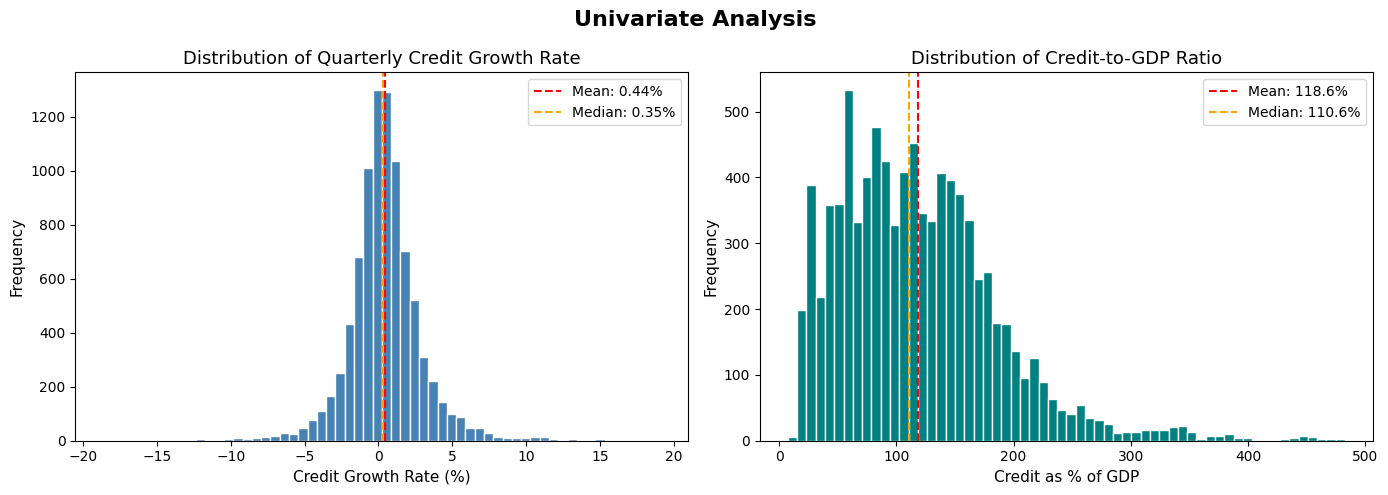

Interpretation:
- Credit growth is approximately normally distributed around 0.44%
- Credit-to-GDP ratio ranges widely, mean=118.6%, median=110.6%


In [16]:
# Univariate Visualizations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Distribution of Credit Growth ---
# Removing extreme outliers for visualization
growth_clean = df['credit_growth'][(df['credit_growth'] > -20) &
                                    (df['credit_growth'] < 20)]
axes[0].hist(growth_clean, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Quarterly Credit Growth Rate', fontsize=13)
axes[0].set_xlabel('Credit Growth Rate (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(growth_clean.mean(), color='red', linestyle='--',
                label=f'Mean: {growth_clean.mean():.2f}%')
axes[0].axvline(growth_clean.median(), color='orange', linestyle='--',
                label=f'Median: {growth_clean.median():.2f}%')
axes[0].legend()

# --- Plot 2: Distribution of Credit-to-GDP ratio ---
axes[1].hist(df['value'], bins=60, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Credit-to-GDP Ratio', fontsize=13)
axes[1].set_xlabel('Credit as % of GDP', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(df['value'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["value"].mean():.1f}%')
axes[1].axvline(df['value'].median(), color='orange', linestyle='--',
                label=f'Median: {df["value"].median():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('univariate_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print(f"- Credit growth is approximately normally distributed around {growth_clean.mean():.2f}%")
print(f"- Credit-to-GDP ratio ranges widely, mean={df['value'].mean():.1f}%, median={df['value'].median():.1f}%")

### 2.2 Multivariate Analysis

**Plot 1 — Top 15 Countries by Average Credit-to-GDP:**
Luxembourg and Hong Kong SAR have the highest credit-to-GDP ratios (300%+),
reflecting their status as major global financial centres. Advanced economies
generally show higher ratios than emerging markets.

**Plot 2 — Global Average Credit-to-GDP Over Time:**
There is a clear upward trend in global credit from the 1950s to present.
Two notable inflection points are visible — the 2008 Global Financial Crisis
caused a temporary slowdown, while COVID-19 in 2020 triggered another sharp
rise as governments and businesses borrowed heavily.

**Plot 3 — Feature Correlation Heatmap:**
The lag features (lag_1 to lag_4) are highly correlated with the current
credit value, confirming that past credit levels are strong predictors.
Credit acceleration shows a negative correlation with credit growth,
suggesting that rapid growth tends to slow down over time.

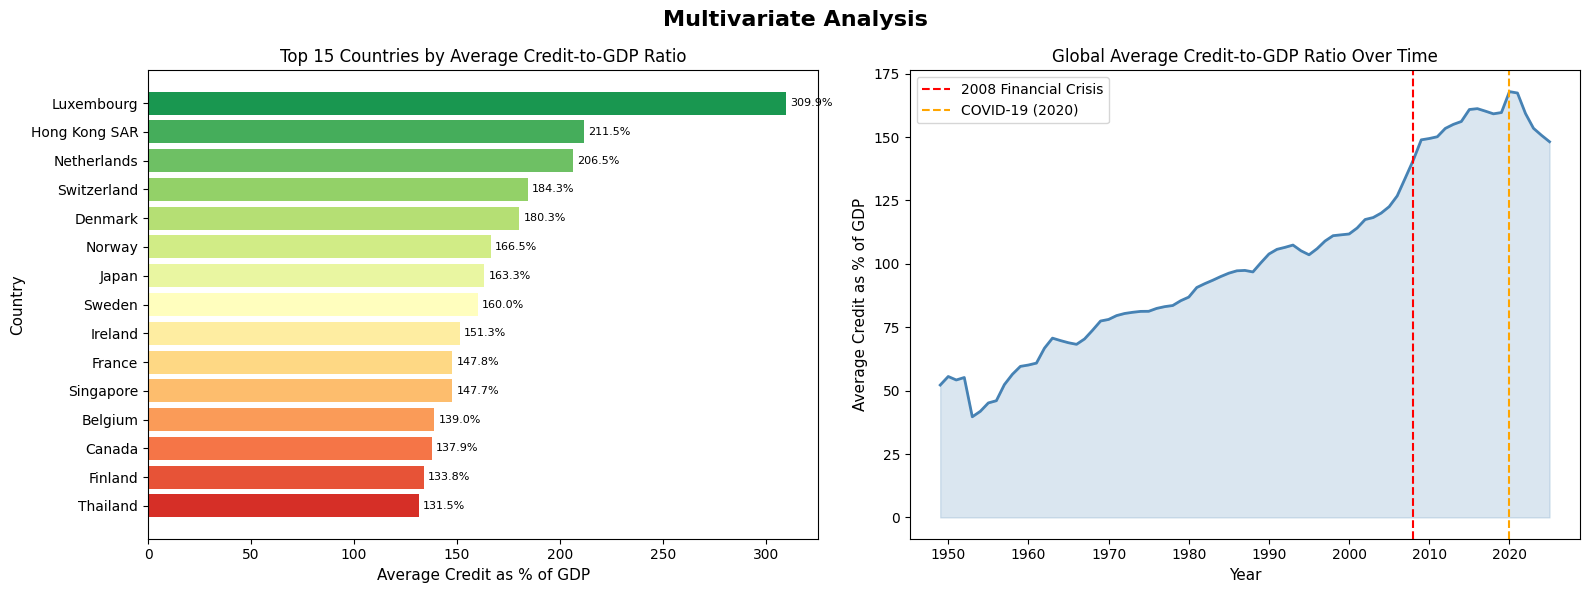

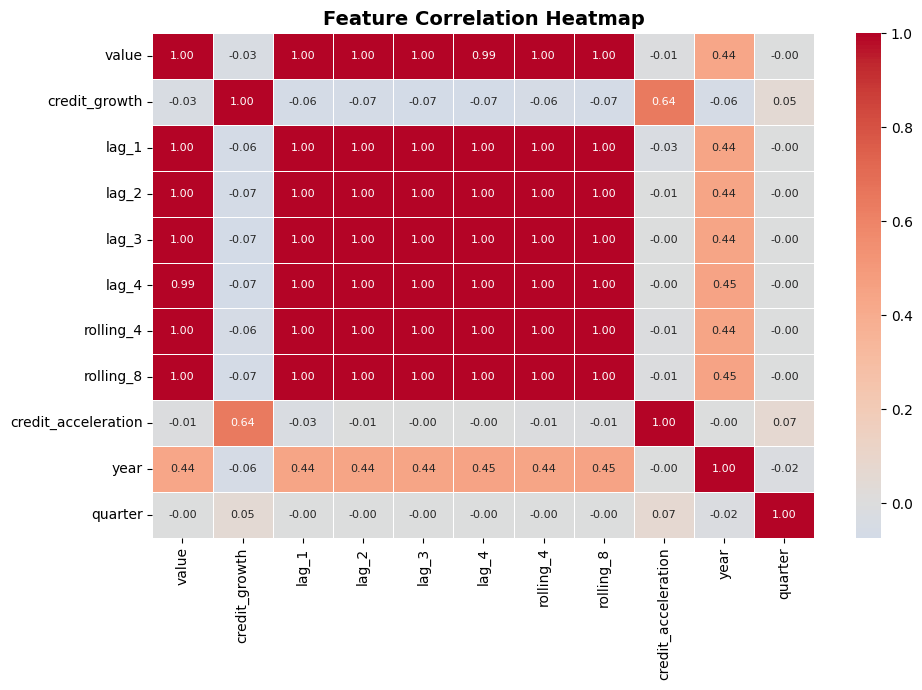

In [17]:
# Multivariate Visualizations

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multivariate Analysis', fontsize=16, fontweight='bold')

# --- Plot 1: Average Credit-to-GDP by Country (top 15) ---
avg_credit = df.groupby('ref_area')['value'].mean().sort_values(ascending=False).head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(avg_credit)))
bars = axes[0].barh(avg_credit.index, avg_credit.values, color=colors)
axes[0].set_title('Top 15 Countries by Average Credit-to-GDP Ratio', fontsize=12)
axes[0].set_xlabel('Average Credit as % of GDP', fontsize=11)
axes[0].set_ylabel('Country', fontsize=11)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
axes[0].invert_yaxis()

# --- Plot 2: Global Average Credit-to-GDP Over Time ---
avg_time = df.groupby('year')['value'].mean()
axes[1].plot(avg_time.index, avg_time.values, color='steelblue', linewidth=2)
axes[1].fill_between(avg_time.index, avg_time.values, alpha=0.2, color='steelblue')
axes[1].axvline(2008, color='red', linestyle='--', linewidth=1.5, label='2008 Financial Crisis')
axes[1].axvline(2020, color='orange', linestyle='--', linewidth=1.5, label='COVID-19 (2020)')
axes[1].set_title('Global Average Credit-to-GDP Ratio Over Time', fontsize=12)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Average Credit as % of GDP', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('multivariate_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Correlation Heatmap ---
plt.figure(figsize=(10, 7))
corr_cols = ['value', 'credit_growth', 'lag_1', 'lag_2',
             'lag_3', 'lag_4', 'rolling_4', 'rolling_8',
             'credit_acceleration', 'year', 'quarter']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Data Preparation for ML

# Removing extreme outliers (beyond 3 standard deviations)
mean = df['credit_growth'].mean()
std = df['credit_growth'].std()
df_ml = df[(df['credit_growth'] >= mean - 3*std) &
           (df['credit_growth'] <= mean + 3*std)].copy()

print(f"Rows after removing outliers: {df_ml.shape[0]}")
print(f"Outliers removed: {df.shape[0] - df_ml.shape[0]}")

# Defining features and target
feature_cols = ['value', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
                'rolling_4', 'rolling_8', 'credit_acceleration',
                'year', 'quarter'] + list(country_dummies.columns)

X = df_ml[feature_cols]
y = df_ml['credit_growth']

# Time-based train/test split (train up to 2015, test after)
split_year = 2015
X_train = X[df_ml['year'] <= split_year]
y_train = y[df_ml['year'] <= split_year]
X_test = X[df_ml['year'] > split_year]
y_test = y[df_ml['year'] > split_year]

print(f"\nTraining samples: {X_train.shape[0]} (up to {split_year})")
print(f"Testing samples:  {X_test.shape[0]} (after {split_year})")
print(f"Number of features: {X_train.shape[1]}")

Rows after removing outliers: 8810
Outliers removed: 74

Training samples: 7141 (up to 2015)
Testing samples:  1669 (after 2015)
Number of features: 53


In [19]:
# Classical ML Models
from sklearn.model_selection import cross_val_score

# Defining models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1, max_iter=10000),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)

    # Testing set evaluation
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Crossing validation on training set (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='r2')

    results[name] = {
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std': round(cv_scores.std(), 4)
    }

    print(f"\n{name}")
    print(f"  Test RMSE:     {rmse:.4f}")
    print(f"  Test R²:       {r2:.4f}")
    print(f"  CV R² Mean:    {cv_scores.mean():.4f}")
    print(f"  CV R² Std:     {cv_scores.std():.4f}")


Linear Regression
  Test RMSE:     1.4576
  Test R²:       0.5971
  CV R² Mean:    0.6965
  CV R² Std:     0.1053

Ridge Regression
  Test RMSE:     1.4570
  Test R²:       0.5974
  CV R² Mean:    0.6965
  CV R² Std:     0.1052


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.617e+00, tolerance: 3.472e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.688e+01, tolerance: 2.987e+00
  model = cd_fast.enet_coordinate_descent(



Lasso Regression
  Test RMSE:     1.3677
  Test R²:       0.6452
  CV R² Mean:    0.7038
  CV R² Std:     0.0904

Gradient Boosting
  Test RMSE:     1.8963
  Test R²:       0.3180
  CV R² Mean:    0.4711
  CV R² Std:     0.0233


In [20]:
# XGBoost
!pip install xgboost -q
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

cv_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')

results['XGBoost'] = {
    'RMSE': round(rmse_xgb, 4),
    'R²': round(r2_xgb, 4),
    'CV R² Mean': round(cv_xgb.mean(), 4),
    'CV R² Std': round(cv_xgb.std(), 4)
}

print(f"XGBoost")
print(f"  Test RMSE:     {rmse_xgb:.4f}")
print(f"  Test R²:       {r2_xgb:.4f}")
print(f"  CV R² Mean:    {cv_xgb.mean():.4f}")
print(f"  CV R² Std:     {cv_xgb.std():.4f}")

# Print full results summary
print("\n=== FULL RESULTS SUMMARY ===")
print(f"{'Model':<25} {'RMSE':>8} {'R²':>8} {'CV R²':>10} {'CV Std':>8}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<25} {res['RMSE']:>8} {res['R²']:>8} {res['CV R² Mean']:>10} {res['CV R² Std']:>8}")

XGBoost
  Test RMSE:     1.5776
  Test R²:       0.5280
  CV R² Mean:    0.6091
  CV R² Std:     0.0297

=== FULL RESULTS SUMMARY ===
Model                         RMSE       R²      CV R²   CV Std
-----------------------------------------------------------------
Linear Regression           1.4576   0.5971     0.6965   0.1053
Ridge Regression             1.457   0.5974     0.6965   0.1052
Lasso Regression            1.3677   0.6452     0.7038   0.0904
Gradient Boosting           1.8963    0.318     0.4711   0.0233
XGBoost                     1.5776    0.528     0.6091   0.0297


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 0 (0.00 B)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Neural Network
  Test RMSE:  2.0490
  Test R²:    0.2038


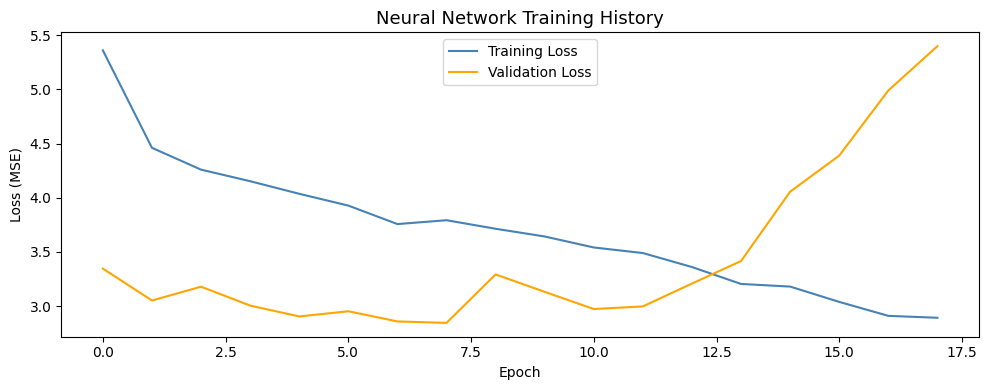

In [21]:
# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Scaling features (neural networks need scaled inputs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building Neural Network
model_nn = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compiling
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_nn.summary()

# Training
history = model_nn.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
    ]
)

# Evaluating
y_pred_nn = model_nn.predict(X_test_scaled).flatten()
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

results['Neural Network'] = {
    'RMSE': round(rmse_nn, 4),
    'R²': round(r2_nn, 4),
    'CV R² Mean': 'N/A',
    'CV R² Std': 'N/A'
}

print(f"\nNeural Network")
print(f"  Test RMSE:  {rmse_nn:.4f}")
print(f"  Test R²:    {r2_nn:.4f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Neural Network Training History', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=150)
plt.show()


Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Improved Neural Network
  Test RMSE:  2.0813
  Test R²:    0.1785


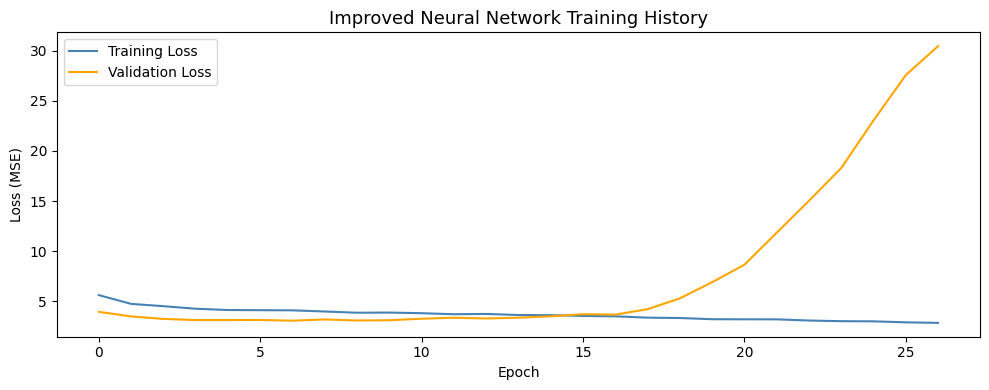

In [22]:
# Improved Neural Network

# Building improved Neural Network
model_nn2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Compiling with lower learning rate
model_nn2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# Training with more epochs and patience
history2 = model_nn2.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=10, verbose=1
        )
    ]
)

# Evaluating
y_pred_nn2 = model_nn2.predict(X_test_scaled).flatten()
rmse_nn2 = np.sqrt(mean_squared_error(y_test, y_pred_nn2))
r2_nn2 = r2_score(y_test, y_pred_nn2)

results['Neural Network (Improved)'] = {
    'RMSE': round(rmse_nn2, 4),
    'R²': round(r2_nn2, 4),
    'CV R² Mean': 'N/A',
    'CV R² Std': 'N/A'
}

print(f"Improved Neural Network")
print(f"  Test RMSE:  {rmse_nn2:.4f}")
print(f"  Test R²:    {r2_nn2:.4f}")

# Plotting training history
plt.figure(figsize=(10, 4))
plt.plot(history2.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history2.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Improved Neural Network Training History', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('nn_improved_history.png', dpi=150)
plt.show()

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Simple Neural Network
  Test RMSE:  1.3548
  Test R²:    0.6519


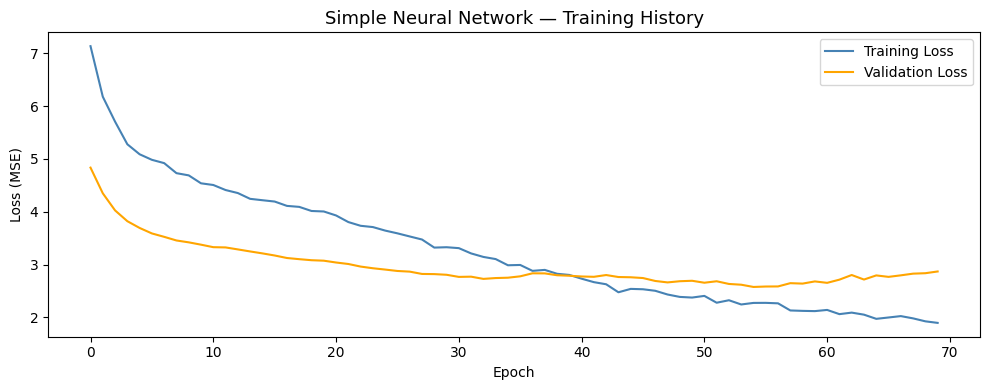


=== FINAL MODEL COMPARISON ===
Model                              RMSE       R²
--------------------------------------------------
Linear Regression                1.4576   0.5971
Ridge Regression                  1.457   0.5974
Lasso Regression                 1.3677   0.6452
Gradient Boosting                1.8963    0.318
XGBoost                          1.5776    0.528
Neural Network                    2.049   0.2038
Neural Network (Improved)        2.0813   0.1785
Neural Network (Final)           1.3548   0.6519


In [23]:
# Simple Neural Network (Final)

# Reseting seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model_nn3 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.1),
    layers.Dense(1)
])

model_nn3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history3 = model_nn3.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=128,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True
        )
    ]
)

# Evaluating
y_pred_nn3 = model_nn3.predict(X_test_scaled).flatten()
rmse_nn3 = np.sqrt(mean_squared_error(y_test, y_pred_nn3))
r2_nn3 = r2_score(y_test, y_pred_nn3)

results['Neural Network (Final)'] = {
    'RMSE': round(rmse_nn3, 4),
    'R²': round(r2_nn3, 4),
    'CV R² Mean': 'N/A',
    'CV R² Std': 'N/A'
}

print(f"Simple Neural Network")
print(f"  Test RMSE:  {rmse_nn3:.4f}")
print(f"  Test R²:    {r2_nn3:.4f}")

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(history3.history['loss'], label='Training Loss', color='steelblue')
plt.plot(history3.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Simple Neural Network — Training History', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.savefig('nn_simple_history.png', dpi=150)
plt.show()

# Final results summary
print("\n=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<30} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for name, res in results.items():
    print(f"{name:<30} {str(res['RMSE']):>8} {str(res['R²']):>8}")

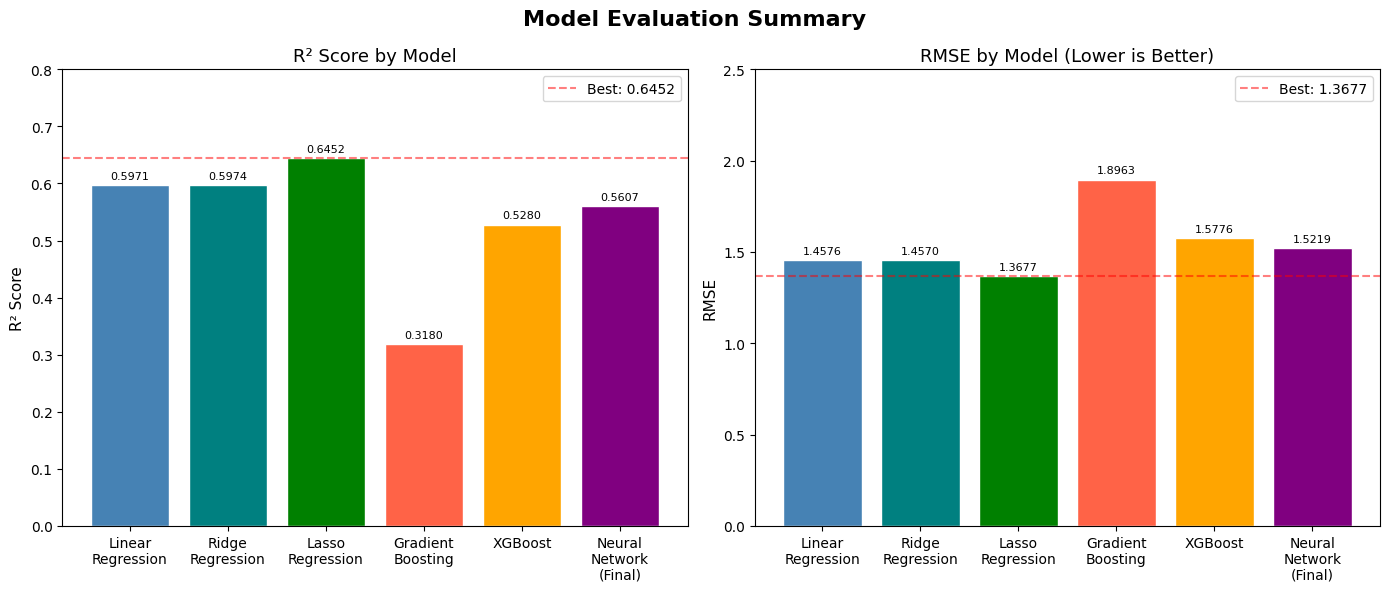

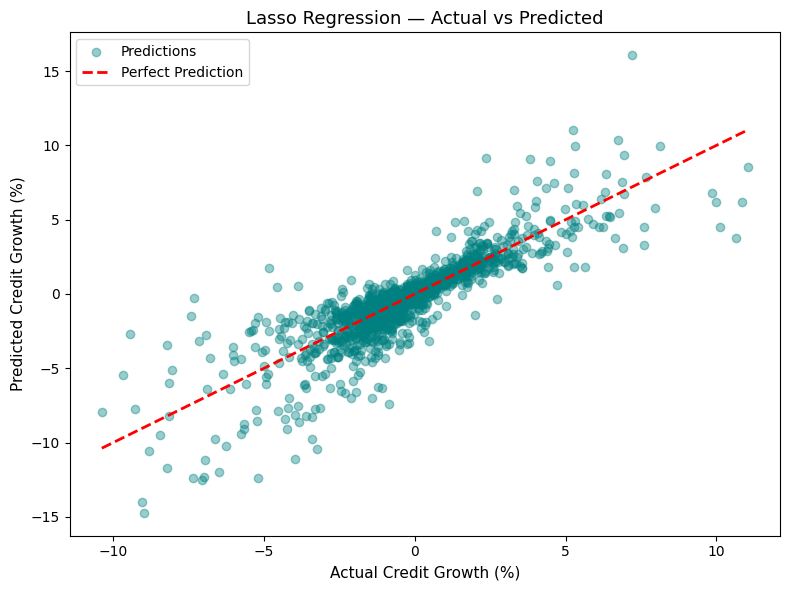

In [24]:
# C Final Model Comparison Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Evaluation Summary', fontsize=16, fontweight='bold')

model_names = ['Linear\nRegression', 'Ridge\nRegression', 'Lasso\nRegression',
               'Gradient\nBoosting', 'XGBoost', 'Neural\nNetwork\n(Final)']
rmse_vals = [1.4576, 1.4570, 1.3677, 1.8963, 1.5776, 1.5219]
r2_vals = [0.5971, 0.5974, 0.6452, 0.3180, 0.5280, 0.5607]
colors = ['steelblue', 'teal', 'green', 'tomato', 'orange', 'purple']

# R² comparison
bars1 = axes[0].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[0].set_title('R² Score by Model', fontsize=13)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_ylim(0, 0.8)
axes[0].bar_label(bars1, fmt='%.4f', padding=3, fontsize=8)
axes[0].axhline(y=max(r2_vals), color='red', linestyle='--',
                alpha=0.5, label=f'Best: {max(r2_vals)}')
axes[0].legend()

# RMSE comparison
bars2 = axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='white')
axes[1].set_title('RMSE by Model (Lower is Better)', fontsize=13)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_ylim(0, 2.5)
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)
axes[1].axhline(y=min(rmse_vals), color='red', linestyle='--',
                alpha=0.5, label=f'Best: {min(rmse_vals)}')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Actual vs Predicted for best model (Lasso)
lasso_model = models['Lasso Regression']
y_pred_lasso = lasso_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.4, color='teal', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Credit Growth (%)', fontsize=11)
plt.ylabel('Predicted Credit Growth (%)', fontsize=11)
plt.title('Lasso Regression — Actual vs Predicted', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_final.png', dpi=150)
plt.show()

In [28]:
# Demo Interface
import ipywidgets as widgets
from IPython.display import display, clear_output

# Getting list of countries
countries = sorted(df['ref_area'].unique().tolist())

# UI Components
title = widgets.HTML(
    value="<h2 style='color:#1B3A5C'>🏦 BIS Credit Growth Predictor</h2>"
          "<p>Enter macroeconomic values to predict quarterly credit growth</p>"
)

country_widget = widgets.Dropdown(
    options=countries,
    value='United States',
    description='Country:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

value_widget = widgets.FloatSlider(
    value=100.0, min=10.0, max=400.0, step=0.1,
    description='Credit-to-GDP (%):',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

lag1_widget = widgets.FloatSlider(
    value=99.0, min=10.0, max=400.0, step=0.1,
    description='Lag 1 (prev quarter):',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

lag2_widget = widgets.FloatSlider(
    value=98.0, min=10.0, max=400.0, step=0.1,
    description='Lag 2 (2 qtrs ago):',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

year_widget = widgets.IntSlider(
    value=2024, min=2016, max=2025, step=1,
    description='Year:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

quarter_widget = widgets.Dropdown(
    options=[1, 2, 3, 4],
    value=1,
    description='Quarter:',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

predict_btn = widgets.Button(
    description='Predict Credit Growth',
    button_style='primary',
    layout=widgets.Layout(width='250px', height='40px')
)

output = widgets.Output()

def on_predict(b):
    with output:
        clear_output()

        # Build input row
        country = country_widget.value
        val = value_widget.value
        lag1 = lag1_widget.value
        lag2 = lag2_widget.value
        lag3 = lag2 - 1.0
        lag4 = lag2 - 2.0
        rolling4 = (val + lag1 + lag2 + lag3) / 4
        rolling8 = rolling4 - 0.5
        accel = ((val - lag1) / lag1 * 100) - ((lag1 - lag2) / lag2 * 100)
        year = year_widget.value
        quarter = quarter_widget.value

        # Building feature vector
        input_data = pd.DataFrame([[val, lag1, lag2, lag3, lag4,
                                    rolling4, rolling8, accel,
                                    year, quarter]],
                                   columns=['value', 'lag_1', 'lag_2', 'lag_3',
                                            'lag_4', 'rolling_4', 'rolling_8',
                                            'credit_acceleration', 'year', 'quarter'])

        # Adding country dummies
        for col in country_dummies.columns:
            country_name = col.replace('country_', '')
            input_data[col] = 1 if country_name == country else 0

        # Predicting
        prediction = lasso_model.predict(input_data)[0]

        # Displaying result
        color = 'green' if prediction > 0 else 'red'
        arrow = '📈' if prediction > 0 else '📉'
        print(f"Country:  {country}")
        print(f"Year/Qtr: {year} Q{quarter}")
        print(f"Current Credit-to-GDP: {val:.1f}%")
        display(widgets.HTML(
            f"<h3 style='color:{color}'>{arrow} Predicted Credit Growth: "
            f"{prediction:.4f}%</h3>"
        ))
        if prediction > 2:
            display(widgets.HTML("<p>⚠️ <b>High credit growth</b> — potential overheating risk</p>"))
        elif prediction < -2:
            display(widgets.HTML("<p>⚠️ <b>Credit contraction</b> — potential economic slowdown</p>"))
        else:
            display(widgets.HTML("<p>✅ <b>Moderate credit growth</b> — within normal range</p>"))

predict_btn.on_click(on_predict)

# Display UI
display(widgets.VBox([
    title,
    country_widget,
    value_widget,
    lag1_widget,
    lag2_widget,
    year_widget,
    quarter_widget,
    predict_btn,
    output
]))

In [26]:
import pickle
from google.colab import files

# Save the trained Lasso model
with open('model.pkl', 'wb') as f:
    pickle.dump(lasso_model, f)

# Save the country dummies columns
import json
with open('country_columns.json', 'w') as f:
    json.dump(list(country_dummies.columns), f)

files.download('model.pkl')
files.download('country_columns.json')

print("Done! Two files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Two files downloaded.


In [27]:
# CELL — SQL: Store & Query BIS Data
import sqlite3

# Create SQLite database
conn = sqlite3.connect('bis_credit.db')
cursor = conn.cursor()

# Create table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS credit_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        country TEXT NOT NULL,
        date TEXT NOT NULL,
        credit_to_gdp REAL,
        credit_growth REAL,
        year INTEGER,
        quarter INTEGER
    )
''')
conn.commit()

# Insert cleaned BIS data into SQL table
df_sql = df[['ref_area', 'date', 'value', 'credit_growth', 'year', 'quarter']].copy()
df_sql.columns = ['country', 'date', 'credit_to_gdp', 'credit_growth', 'year', 'quarter']
df_sql.to_sql('credit_data', conn, if_exists='replace', index=False)

print(f"Inserted {len(df_sql)} rows into SQL database")

# ── SQL QUERIES ──────────────────────────────

# Query 1: Top 10 countries by average credit-to-GDP
print("\n📊 Query 1: Top 10 Countries by Average Credit-to-GDP")
q1 = pd.read_sql_query('''
    SELECT country,
           ROUND(AVG(credit_to_gdp), 2) AS avg_credit_gdp,
           COUNT(*) AS num_quarters
    FROM credit_data
    GROUP BY country
    ORDER BY avg_credit_gdp DESC
    LIMIT 10
''', conn)
print(q1.to_string(index=False))

# Query 2: Average credit growth by quarter
print("\n📊 Query 2: Average Credit Growth by Quarter of Year")
q2 = pd.read_sql_query('''
    SELECT quarter,
           ROUND(AVG(credit_growth), 4) AS avg_growth,
           ROUND(MIN(credit_growth), 4) AS min_growth,
           ROUND(MAX(credit_growth), 4) AS max_growth
    FROM credit_data
    GROUP BY quarter
    ORDER BY quarter
''', conn)
print(q2.to_string(index=False))

# Query 3: Countries with highest credit growth in last 5 years
print("\n📊 Query 3: Highest Average Credit Growth (2020–2025)")
q3 = pd.read_sql_query('''
    SELECT country,
           ROUND(AVG(credit_growth), 4) AS avg_growth,
           ROUND(AVG(credit_to_gdp), 2) AS avg_credit_gdp
    FROM credit_data
    WHERE year >= 2020
    GROUP BY country
    ORDER BY avg_growth DESC
    LIMIT 10
''', conn)
print(q3.to_string(index=False))

# Query 4: Crisis period analysis
print("\n📊 Query 4: Credit Growth Before vs After 2008 Crisis")
q4 = pd.read_sql_query('''
    SELECT
        CASE WHEN year < 2008 THEN 'Pre-2008'
             WHEN year BETWEEN 2008 AND 2012 THEN 'Crisis (2008-2012)'
             ELSE 'Post-2012'
        END AS period,
        ROUND(AVG(credit_growth), 4) AS avg_growth,
        COUNT(*) AS observations
    FROM credit_data
    GROUP BY period
    ORDER BY MIN(year)
''', conn)
print(q4.to_string(index=False))

conn.close()
print("\n✅ SQL database created and queries completed!")

Inserted 8884 rows into SQL database

📊 Query 1: Top 10 Countries by Average Credit-to-GDP
      country  avg_credit_gdp  num_quarters
   Luxembourg          309.87           116
Hong Kong SAR          211.55           181
  Netherlands          206.48           252
  Switzerland          184.33           253
      Denmark          180.28           229
       Norway          166.47           253
        Japan          163.29           237
       Sweden          159.98           252
      Ireland          151.26           211
       France          147.75           217

📊 Query 2: Average Credit Growth by Quarter of Year
 quarter  avg_growth  min_growth  max_growth
       1      0.1845    -77.4775     91.1168
       2      0.5593    -35.1852    162.6667
       3      0.3596    -28.7373     82.7411
       4      0.8703    -24.0326    103.6111

📊 Query 3: Highest Average Credit Growth (2020–2025)
     country  avg_growth  avg_credit_gdp
Saudi Arabia      1.7174           67.60
      Brazi

In [32]:
# ============================================
# CELL — Data Engineering Pipeline
# ============================================
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class BISCreditPipeline:
    def __init__(self, db_path='bis_credit_pipeline.db'):
        self.db_path = db_path
        self.conn = None
        self.run_log = []

    def connect(self):
        self.conn = sqlite3.connect(self.db_path)
        logger.info("✅ Database connection established")

    def disconnect(self):
        if self.conn:
            self.conn.close()
            logger.info("✅ Database connection closed")

    def extract(self, filepath):
        logger.info("📥 STEP 1: Extracting data...")
        start = datetime.now()
        df_raw = pd.read_csv(filepath, sep=',', encoding='utf-8',
                             quotechar='"', on_bad_lines='warn', engine='python')
        records = len(df_raw)
        logger.info(f"   Extracted {records:,} raw records")
        self.run_log.append({'step': 'extract', 'records': records, 'status': 'success', 'time': str(datetime.now())})
        return df_raw

    def transform(self, df_raw):
        logger.info("🔄 STEP 2: Transforming data...")
        start = datetime.now()
        df = df_raw.copy()

        # Rename columns
        df.columns = [
            'dataflow', 'series_key', 'frequency', 'ref_area', 'borrower_sector',
            'lending_sector', 'valuation', 'currency_type', 'adjustment',
            'date', 'value', 'position', 'unit_mult', 'currency',
            'series_name', 'col16', 'obs_status', 'col18', 'col19', 'col20'
        ]

        # Remap columns
        df = df.rename(columns={
            'ref_area': 'drop1', 'borrower_sector': 'ref_area',
            'lending_sector': 'borrower_sector', 'valuation': 'lending_sector',
            'currency_type': 'valuation', 'adjustment': 'currency_type',
            'date': 'adjustment', 'value': 'date', 'position': 'value'
        })

        # Clean
        df['ref_area'] = df['ref_area'].str.split(': ').str[-1]
        df['lending_sector'] = df['lending_sector'].str.split(': ').str[-1]
        df['currency_type'] = df['currency_type'].str.split(': ').str[-1]

        # Filter
        df = df[df['currency_type'] == 'Percentage of GDP']
        df = df[df['lending_sector'] == 'All sectors']

        # Remove duplicates by averaging
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df = df.dropna(subset=['value'])
        df = df.groupby(['ref_area', 'date'], as_index=False)['value'].mean()

        # Remove aggregates
        aggregates = ['Euro area', 'G20 economies', 'All reporting economies',
                      'Emerging market economies (aggregate)', 'Advanced economies']
        df = df[~df['ref_area'].isin(aggregates)]

        # Sort
        df = df[['ref_area', 'date', 'value']].copy()
        df = df.sort_values(['ref_area', 'date']).reset_index(drop=True)

        # Feature engineering
        df['credit_growth'] = df.groupby('ref_area')['value'].pct_change() * 100
        df['lag_1'] = df.groupby('ref_area')['value'].shift(1)
        df['lag_2'] = df.groupby('ref_area')['value'].shift(2)
        df['lag_3'] = df.groupby('ref_area')['value'].shift(3)
        df['lag_4'] = df.groupby('ref_area')['value'].shift(4)
        df['rolling_4'] = df.groupby('ref_area')['value'].transform(lambda x: x.rolling(4).mean())
        df['rolling_8'] = df.groupby('ref_area')['value'].transform(lambda x: x.rolling(8).mean())
        df['credit_acceleration'] = df.groupby('ref_area')['credit_growth'].diff()
        df['year'] = df['date'].str.split('-').str[0].astype(int)
        df['quarter'] = df['date'].str.split('-Q').str[1].astype(int)
        df = df.dropna()

        # Remove outliers
        mean = df['credit_growth'].mean()
        std = df['credit_growth'].std()
        df = df[(df['credit_growth'] >= mean - 3*std) &
                (df['credit_growth'] <= mean + 3*std)]

        # Validation
        assert df.duplicated(subset=['ref_area', 'date']).sum() == 0, "Duplicates found!"
        assert df.isnull().sum().sum() == 0, "Null values found!"
        assert len(df) > 1000, "Too few records!"

        logger.info(f"   Transformed to {len(df):,} clean records")
        logger.info(f"   Countries: {df['ref_area'].nunique()}")
        logger.info(f"   Date range: {df['date'].min()} to {df['date'].max()}")
        self.run_log.append({'step': 'transform', 'records': len(df), 'status': 'success', 'time': str(datetime.now())})
        return df

    def load(self, df):
        logger.info("💾 STEP 3: Loading data into database...")
        cursor = self.conn.cursor()
        cursor.execute('''CREATE TABLE IF NOT EXISTS pipeline_runs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            run_date TEXT, step TEXT, records INTEGER,
            status TEXT, duration_seconds REAL)''')
        cursor.execute('''CREATE TABLE IF NOT EXISTS credit_features (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            country TEXT, date TEXT, credit_to_gdp REAL,
            credit_growth REAL, lag_1 REAL, lag_2 REAL,
            lag_3 REAL, lag_4 REAL, rolling_4 REAL,
            rolling_8 REAL, credit_acceleration REAL,
            year INTEGER, quarter INTEGER, loaded_at TEXT)''')
        df_load = df.rename(columns={'ref_area': 'country', 'value': 'credit_to_gdp'})
        df_load['loaded_at'] = str(datetime.now())
        df_load.to_sql('credit_features', self.conn, if_exists='replace', index=False)
        logger.info(f"   Loaded {len(df):,} records")
        self.run_log.append({'step': 'load', 'records': len(df), 'status': 'success', 'time': str(datetime.now())})
        return True

    def predict(self, model, country_dummies):
        logger.info("🤖 STEP 4: Generating predictions...")
        latest = pd.read_sql_query('''
            SELECT country, date, credit_to_gdp, lag_1, lag_2, lag_3, lag_4,
                   rolling_4, rolling_8, credit_acceleration, year, quarter
            FROM credit_features
            WHERE (country, date) IN (
                SELECT country, MAX(date) FROM credit_features GROUP BY country)
            ORDER BY country''', self.conn)

        feature_cols = ['credit_to_gdp', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
                        'rolling_4', 'rolling_8', 'credit_acceleration', 'year', 'quarter']
        X_latest = latest[feature_cols].copy()
        X_latest.columns = ['value', 'lag_1', 'lag_2', 'lag_3', 'lag_4',
                             'rolling_4', 'rolling_8', 'credit_acceleration', 'year', 'quarter']

        for col in country_dummies.columns:
            country_name = col.replace('country_', '')
            X_latest[col] = latest['country'].apply(lambda x: 1 if x == country_name else 0)

        latest['predicted_growth'] = model.predict(X_latest)
        latest['prediction_date'] = str(datetime.now())
        latest[['country', 'date', 'credit_to_gdp', 'predicted_growth', 'prediction_date']].to_sql(
            'predictions', self.conn, if_exists='replace', index=False)

        logger.info(f"   Generated predictions for {len(latest)} countries")
        self.run_log.append({'step': 'predict', 'records': len(latest), 'status': 'success', 'time': str(datetime.now())})
        return latest

    def report(self):
        logger.info("📋 STEP 5: Generating pipeline report...")
        print("\n" + "="*55)
        print("    BIS CREDIT GROWTH PIPELINE — RUN REPORT")
        print("="*55)
        print(f"  Run Date:  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Steps Run: {len(self.run_log)}")
        print("-"*55)
        for log in self.run_log:
            print(f"  ✅ {log['step'].upper():<12} {log['records']:>6,} records   {log['status']}")
        print("="*55)
        preds = pd.read_sql_query('''
            SELECT country, credit_to_gdp,
                   ROUND(predicted_growth, 4) as predicted_growth
            FROM predictions ORDER BY predicted_growth DESC LIMIT 5''', self.conn)
        print("\n  🏆 Top 5 Countries by Predicted Credit Growth:")
        print(preds.to_string(index=False))
        print("="*55)

    def run(self, filepath, model, country_dummies):
        logger.info("🚀 Starting BIS Credit Growth Pipeline...")
        self.connect()
        try:
            df_raw = self.extract(filepath)
            df_clean = self.transform(df_raw)
            self.load(df_clean)
            predictions = self.predict(model, country_dummies)
            self.report()
            logger.info("🎉 Pipeline completed successfully!")
            return df_clean, predictions
        except Exception as e:
            logger.error(f"❌ Pipeline failed: {e}")
            raise
        finally:
            self.disconnect()

# Run the pipeline
pipeline = BISCreditPipeline()
df_pipeline, predictions = pipeline.run(
    filepath='WS_TC_csv_flat.csv',
    model=lasso_model,
    country_dummies=country_dummies
)


    BIS CREDIT GROWTH PIPELINE — RUN REPORT
  Run Date:  2026-04-30 08:53:23
  Steps Run: 4
-------------------------------------------------------
  ✅ EXTRACT      186,082 records   success
  ✅ TRANSFORM     8,814 records   success
  ✅ LOAD          8,814 records   success
  ✅ PREDICT          43 records   success

  🏆 Top 5 Countries by Predicted Credit Growth:
  country  credit_to_gdp  predicted_growth
 Thailand         122.80            1.9148
   Mexico          42.74            1.6840
Argentina          48.26            1.5919
Singapore         166.24            1.3591
Indonesia          39.98            1.3422


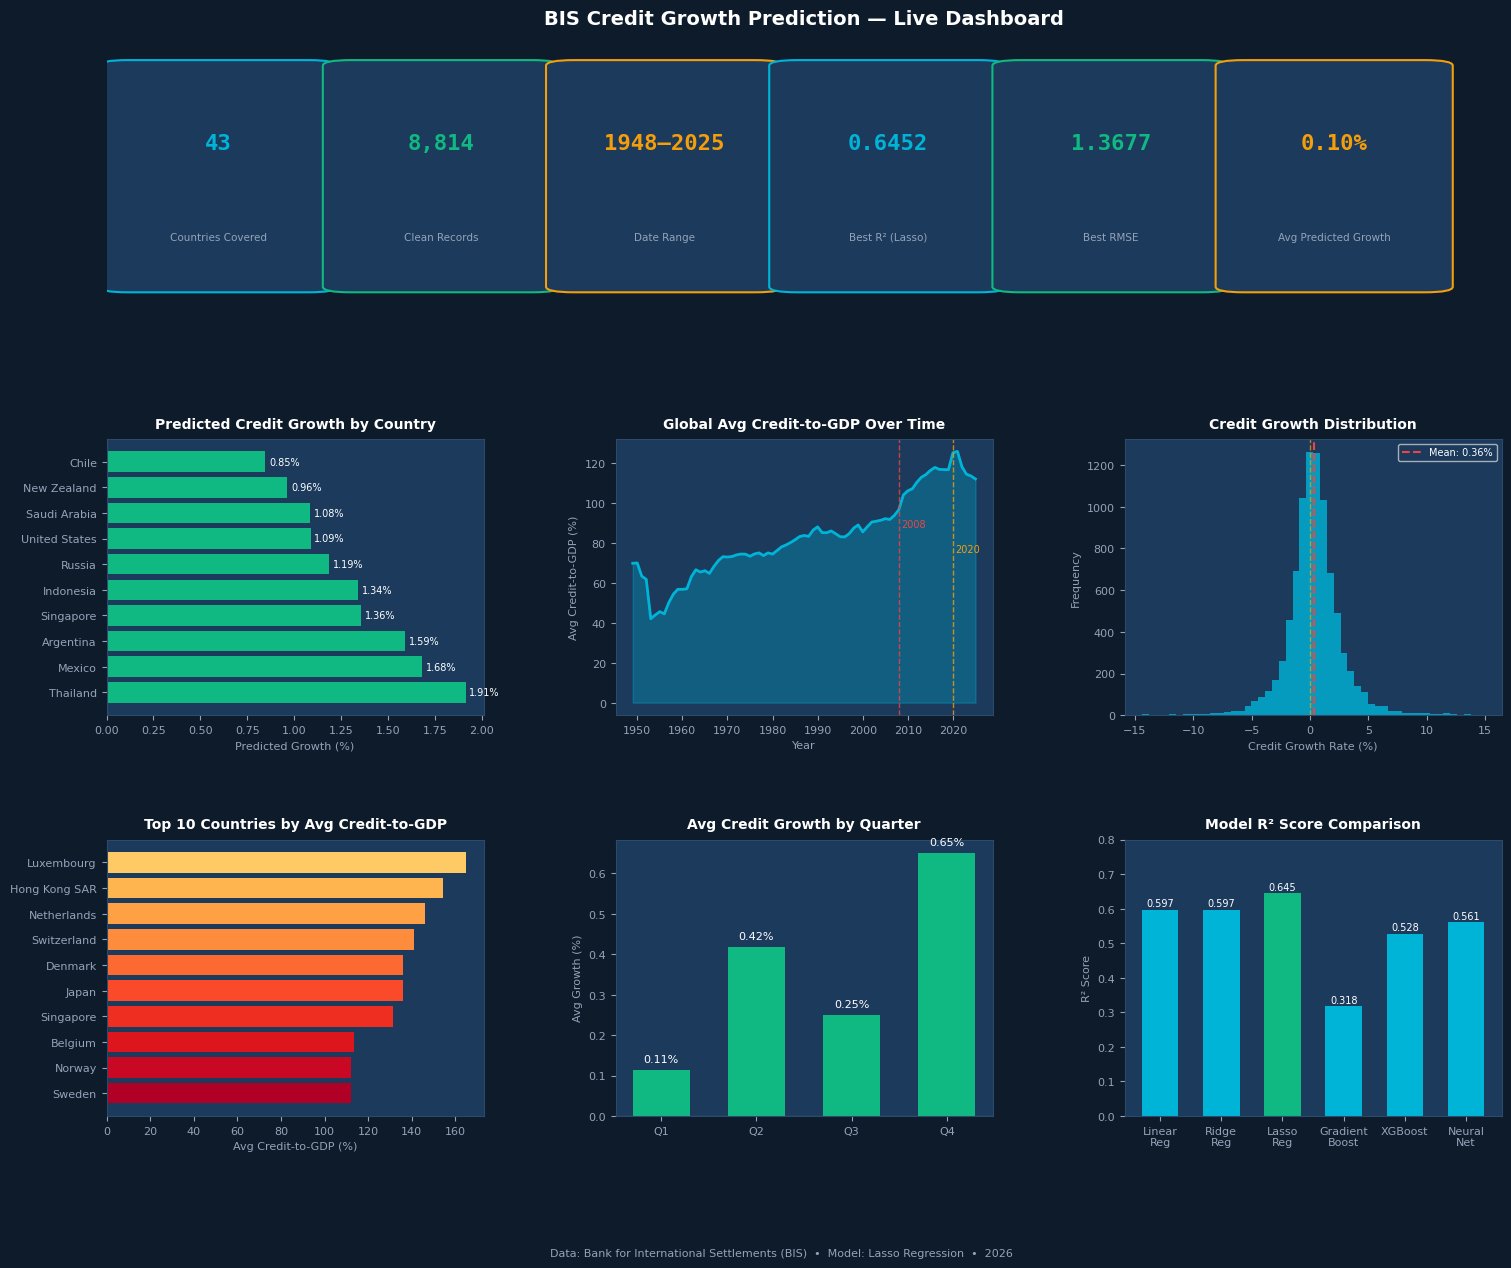

✅ Dashboard saved as dashboard.png


In [33]:
# ============================================
# CELL — Interactive Dashboard
# ============================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import sqlite3
import pandas as pd
import numpy as np

# Load data from pipeline database
conn = sqlite3.connect('bis_credit_pipeline.db')

df_dash = pd.read_sql_query("SELECT * FROM credit_features", conn)
df_preds = pd.read_sql_query("SELECT * FROM predictions ORDER BY predicted_growth DESC", conn)
conn.close()

# ── DASHBOARD LAYOUT ─────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0D1B2A')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

TEAL = '#00B4D8'
ORANGE = '#F59E0B'
GREEN = '#10B981'
RED = '#EF4444'
WHITE = '#FFFFFF'
GRAY = '#94A3B8'
NAVY = '#0D1B2A'
NAVYMID = '#1B3A5C'

def style_ax(ax, title):
    ax.set_facecolor(NAVYMID)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2D4A6B')
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=8)

# ── CHART 1: KPI Cards (top row) ─────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor(NAVY)
ax_kpi.axis('off')

kpis = [
    ("43", "Countries Covered", TEAL),
    ("8,814", "Clean Records", GREEN),
    ("1948–2025", "Date Range", ORANGE),
    ("0.6452", "Best R² (Lasso)", TEAL),
    ("1.3677", "Best RMSE", GREEN),
    (f"{df_preds['predicted_growth'].mean():.2f}%", "Avg Predicted Growth", ORANGE),
]

for i, (val, label, color) in enumerate(kpis):
    x = 0.08 + i * 0.16
    ax_kpi.add_patch(mpatches.FancyBboxPatch(
        (x - 0.065, 0.1), 0.13, 0.8,
        boxstyle="round,pad=0.02",
        facecolor=NAVYMID, edgecolor=color, linewidth=1.5,
        transform=ax_kpi.transAxes
    ))
    ax_kpi.text(x, 0.62, val, transform=ax_kpi.transAxes,
                ha='center', va='center', color=color,
                fontsize=16, fontweight='bold', fontfamily='monospace')
    ax_kpi.text(x, 0.28, label, transform=ax_kpi.transAxes,
                ha='center', va='center', color=GRAY, fontsize=7.5)

ax_kpi.set_title('BIS Credit Growth Prediction — Live Dashboard',
                  color=WHITE, fontsize=14, fontweight='bold', pad=10)

# ── CHART 2: Top 10 predicted growth (bar) ───
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, 'Predicted Credit Growth by Country')
top10 = df_preds.head(10)
colors_bar = [GREEN if v > 0 else RED for v in top10['predicted_growth']]
bars = ax2.barh(top10['country'], top10['predicted_growth'], color=colors_bar, edgecolor='none')
ax2.set_xlabel('Predicted Growth (%)', color=GRAY, fontsize=8)
ax2.axvline(0, color=GRAY, linewidth=0.8, linestyle='--')
for bar, val in zip(bars, top10['predicted_growth']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', color=WHITE, fontsize=7)

# ── CHART 3: Credit-to-GDP over time (line) ──
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, 'Global Avg Credit-to-GDP Over Time')
avg_time = df_dash.groupby('year')['credit_to_gdp'].mean()
ax3.fill_between(avg_time.index, avg_time.values, alpha=0.3, color=TEAL)
ax3.plot(avg_time.index, avg_time.values, color=TEAL, linewidth=2)
ax3.axvline(2008, color=RED, linestyle='--', linewidth=1, alpha=0.8)
ax3.axvline(2020, color=ORANGE, linestyle='--', linewidth=1, alpha=0.8)
ax3.text(2008.5, avg_time.max() * 0.7, '2008', color=RED, fontsize=7)
ax3.text(2020.5, avg_time.max() * 0.6, '2020', color=ORANGE, fontsize=7)
ax3.set_xlabel('Year', color=GRAY, fontsize=8)
ax3.set_ylabel('Avg Credit-to-GDP (%)', color=GRAY, fontsize=8)

# ── CHART 4: Credit growth distribution ──────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4, 'Credit Growth Distribution')
growth_clean = df_dash['credit_growth'][(df_dash['credit_growth'] > -15) &
                                         (df_dash['credit_growth'] < 15)]
ax4.hist(growth_clean, bins=50, color=TEAL, alpha=0.8, edgecolor='none')
ax4.axvline(growth_clean.mean(), color=RED, linestyle='--', linewidth=1.5,
            label=f'Mean: {growth_clean.mean():.2f}%')
ax4.axvline(0, color=ORANGE, linestyle='--', linewidth=1, alpha=0.7)
ax4.set_xlabel('Credit Growth Rate (%)', color=GRAY, fontsize=8)
ax4.set_ylabel('Frequency', color=GRAY, fontsize=8)
ax4.legend(fontsize=7, facecolor=NAVYMID, labelcolor=WHITE)

# ── CHART 5: Top countries by avg credit ─────
ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, 'Top 10 Countries by Avg Credit-to-GDP')
top_countries = df_dash.groupby('country')['credit_to_gdp'].mean().sort_values(ascending=False).head(10)
gradient = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_countries)))
ax5.barh(top_countries.index[::-1], top_countries.values[::-1],
         color=gradient[::-1], edgecolor='none')
ax5.set_xlabel('Avg Credit-to-GDP (%)', color=GRAY, fontsize=8)

# ── CHART 6: Quarterly credit growth trend ───
ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, 'Avg Credit Growth by Quarter')
q_avg = df_dash.groupby('quarter')['credit_growth'].mean()
bar_colors = [GREEN if v > 0 else RED for v in q_avg.values]
ax6.bar(['Q1', 'Q2', 'Q3', 'Q4'], q_avg.values, color=bar_colors, edgecolor='none', width=0.6)
ax6.set_ylabel('Avg Growth (%)', color=GRAY, fontsize=8)
ax6.axhline(0, color=GRAY, linewidth=0.8)
for i, v in enumerate(q_avg.values):
    ax6.text(i, v + 0.02, f'{v:.2f}%', ha='center', color=WHITE, fontsize=8)

# ── CHART 7: Model comparison ─────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, 'Model R² Score Comparison')
models = ['Linear\nReg', 'Ridge\nReg', 'Lasso\nReg', 'Gradient\nBoost', 'XGBoost', 'Neural\nNet']
r2_scores = [0.5971, 0.5974, 0.6452, 0.3180, 0.5280, 0.5607]
bar_colors2 = [GREEN if v == max(r2_scores) else TEAL for v in r2_scores]
bars7 = ax7.bar(models, r2_scores, color=bar_colors2, edgecolor='none', width=0.6)
ax7.set_ylabel('R² Score', color=GRAY, fontsize=8)
ax7.set_ylim(0, 0.8)
for bar, val in zip(bars7, r2_scores):
    ax7.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.3f}', ha='center', color=WHITE, fontsize=7)

# Footer
fig.text(0.5, 0.01,
         'Data: Bank for International Settlements (BIS)  •  Model: Lasso Regression  •  2026',
         ha='center', color=GRAY, fontsize=8)

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=NAVY, edgecolor='none')
plt.show()
print("✅ Dashboard saved as dashboard.png")

In [34]:
# Save dashboard for use in slides
from google.colab import files
files.download('dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>